# New Section

In [3]:
import pandas as pd

data = pd.read_csv("heart.csv")
print(data.head(10))

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   
5   58    0   0       100   248    0        0      122      0      1.0      1   
6   58    1   0       114   318    0        2      140      0      4.4      0   
7   55    1   0       160   289    0        0      145      1      0.8      1   
8   46    1   0       120   249    0        0      144      0      0.8      2   
9   54    1   0       122   286    0        0      116      1      3.2      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0 


================ DATASET ================

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Shape
(1025, 14)

Columns
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null

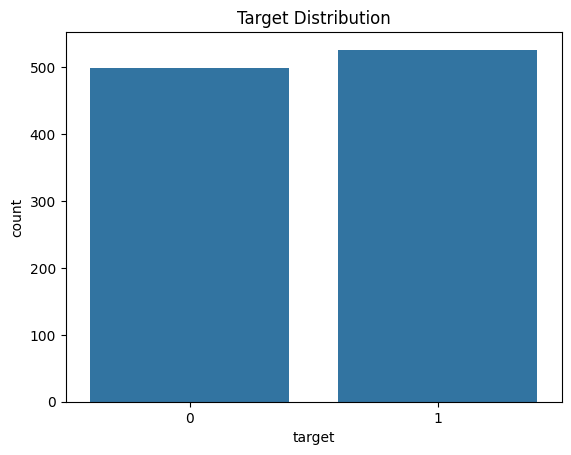

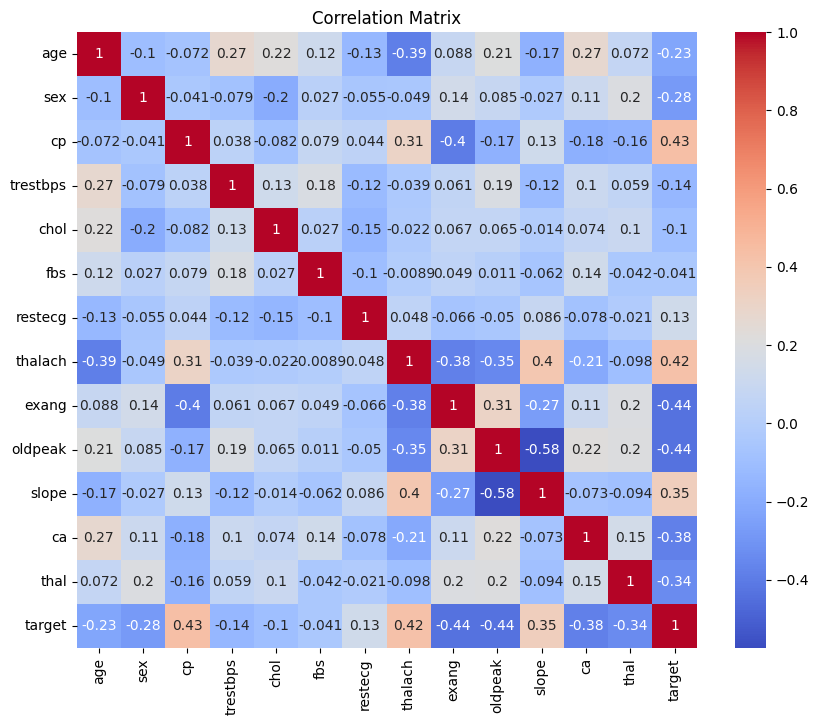


CRISP-DM Accuracy
0.9853658536585366

Confusion Matrix
[[102   0]
 [  3 100]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205


Prediction for Sample Record
[1]

SEMMA

Sample Size
(718, 14)

Explore Data
              age        sex          cp    trestbps        chol         fbs  \
count  718.000000  718.00000  718.000000  718.000000  718.000000  718.000000   
mean    54.481894    0.70195    0.952646  131.422006  247.019499    0.154596   
std      9.109841    0.45772    1.039251   17.498082   52.004019    0.361771   
min     29.000000    0.00000    0.000000   94.000000  126.000000    0.000000   
25%     47.000000    0.00000    0.000000  120.000000  212.000000    0.000000   
50%     56.00

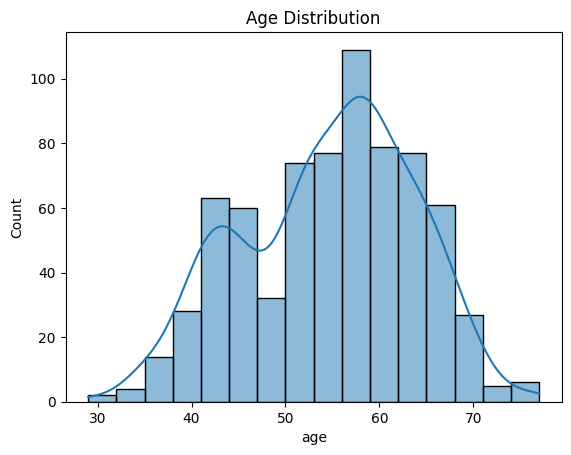

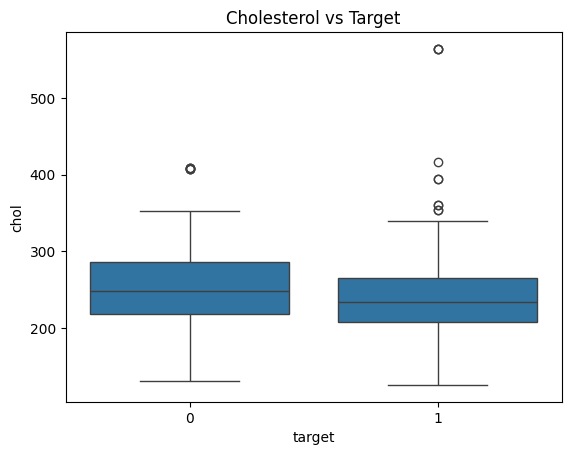


SEMMA Accuracy
0.9861111111111112

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        79
           1       0.97      1.00      0.98        65

    accuracy                           0.99       144
   macro avg       0.99      0.99      0.99       144
weighted avg       0.99      0.99      0.99       144


KDD

Selected Dataset
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3      

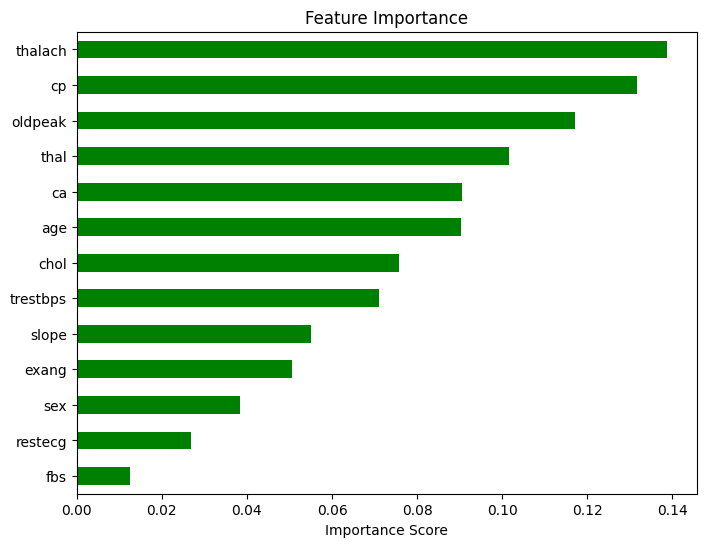


============== COMPLETED SUCCESSFULLY ==============


In [4]:
# ============================================================
# HEART DISEASE PREDICTION
# CRISP-DM + SEMMA + KDD (Single Python Program)
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("heart.csv")

print("\n================ DATASET ================\n")
print(df.head())

# ============================================================
# Basic Functions
# ============================================================

print("\nDataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nUnique Values")
print(df.nunique())

# ============================================================
# CRISP-DM
# ============================================================

print("\n======================================")
print("CRISP-DM")
print("======================================")

# 1. Business Understanding
print("\nBusiness Understanding")
print("Goal: Predict whether a patient has heart disease.")

# 2. Data Understanding
print("\nData Understanding")

print(df.describe())

print("\nTarget Distribution")
print(df['target'].value_counts())

sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 3. Data Preparation

X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# 4. Modeling

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

# 5. Evaluation

prediction = model.predict(X_test)

print("\nCRISP-DM Accuracy")
print(accuracy_score(y_test, prediction))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, prediction))

print("\nClassification Report")
print(classification_report(y_test, prediction))

# 6. Deployment

sample = X_test[:1]

result = model.predict(sample)

print("\nPrediction for Sample Record")
print(result)

# ============================================================
# SEMMA
# ============================================================

print("\n======================================")
print("SEMMA")
print("======================================")

# Sample

sample_df = df.sample(frac=0.7, random_state=1)

print("\nSample Size")
print(sample_df.shape)

# Explore

print("\nExplore Data")
print(sample_df.describe())

sns.histplot(sample_df["age"], kde=True)
plt.title("Age Distribution")
plt.show()

sns.boxplot(x="target", y="chol", data=sample_df)
plt.title("Cholesterol vs Target")
plt.show()

# Modify

X_semma = sample_df.drop("target", axis=1)
y_semma = sample_df["target"]

X_semma = scaler.fit_transform(X_semma)

# Model

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_semma,
    y_semma,
    test_size=0.2,
    random_state=42
)

semma_model = RandomForestClassifier(random_state=42)

semma_model.fit(X_train_s, y_train_s)

# Assess

pred_semma = semma_model.predict(X_test_s)

print("\nSEMMA Accuracy")
print(accuracy_score(y_test_s, pred_semma))

print("\nClassification Report")
print(classification_report(y_test_s, pred_semma))

# ============================================================
# KDD
# ============================================================

print("\n======================================")
print("KDD")
print("======================================")

# Selection

selected = df.copy()

print("\nSelected Dataset")
print(selected.head())

# Preprocessing

print("\nMissing Values")
print(selected.isnull().sum())

selected = selected.drop_duplicates()

print("\nShape After Removing Duplicates")
print(selected.shape)

# Transformation

X_kdd = selected.drop("target", axis=1)
y_kdd = selected["target"]

X_kdd = scaler.fit_transform(X_kdd)

# Data Mining

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_kdd,
    y_kdd,
    test_size=0.2,
    random_state=42
)

kdd_model = RandomForestClassifier(random_state=42)

kdd_model.fit(X_train_k, y_train_k)

# Interpretation

pred_kdd = kdd_model.predict(X_test_k)

print("\nKDD Accuracy")
print(accuracy_score(y_test_k, pred_kdd))

print("\nConfusion Matrix")
print(confusion_matrix(y_test_k, pred_kdd))

print("\nClassification Report")
print(classification_report(y_test_k, pred_kdd))

# ============================================================
# Feature Importance
# ============================================================

importance = pd.Series(
    kdd_model.feature_importances_,
    index=df.drop("target", axis=1).columns
)

importance = importance.sort_values()

plt.figure(figsize=(8,6))
importance.plot(kind="barh", color="green")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

print("\n============== COMPLETED SUCCESSFULLY ==============")